In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("student_performance_data.csv")

In [12]:
df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Assignment Score,Midterm Score,Absences,Participation in Extracurricular Activities,Parent Education Level,Passed
0,17.98,69.86,73.22,44.27,57.45,1,Yes,High School,Yes
1,14.17,74.33,72.25,57.23,81.20,4,No,Bachelor,Yes
2,18.89,70.83,53.95,63.78,61.83,3,No,Associate,No
3,24.14,79.33,76.69,74.10,66.45,10,Yes,Master,Yes
4,13.60,92.37,45.65,86.34,76.48,6,Yes,Bachelor,Yes


In [13]:
df.shape

(10000, 9)

# Exploratory Data Analysis (EDA)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Study Hours per Week                         10000 non-null  float64
 1   Attendance Rate                              10000 non-null  float64
 2   Previous Grades                              10000 non-null  float64
 3   Assignment Score                             10000 non-null  float64
 4   Midterm Score                                10000 non-null  float64
 5   Absences                                     10000 non-null  int64  
 6   Participation in Extracurricular Activities  10000 non-null  str    
 7   Parent Education Level                       10000 non-null  str    
 8   Passed                                       10000 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 703.3 KB


### Target Variable Analysis

In [15]:
df["Passed"].value_counts()

Passed
Yes    5000
No     5000
Name: count, dtype: int64

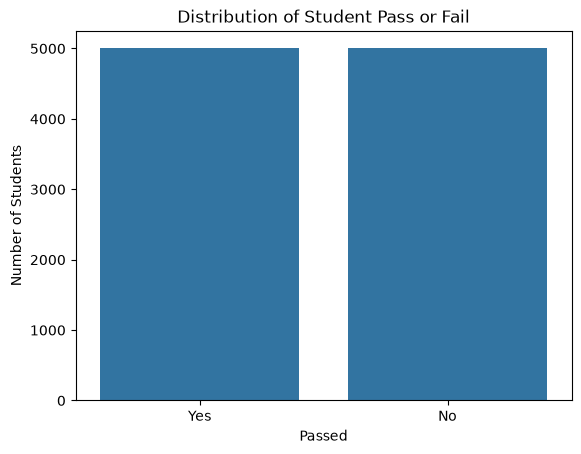

In [16]:
sns.countplot(x="Passed", data=df)
plt.title("Distribution of Student Pass or Fail")
plt.xlabel("Passed")
plt.ylabel("Number of Students")
plt.show()

### Distribution of Numerical Features

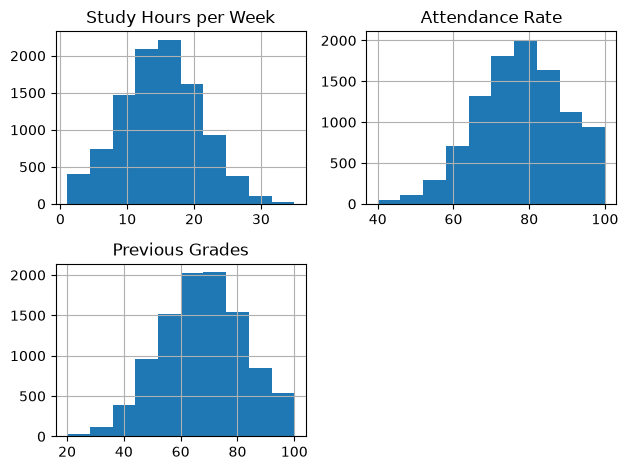

In [17]:
df[["Study Hours per Week", "Attendance Rate", "Previous Grades"]].hist()
plt.tight_layout()
plt.show()

### Feature Relationship Analysis

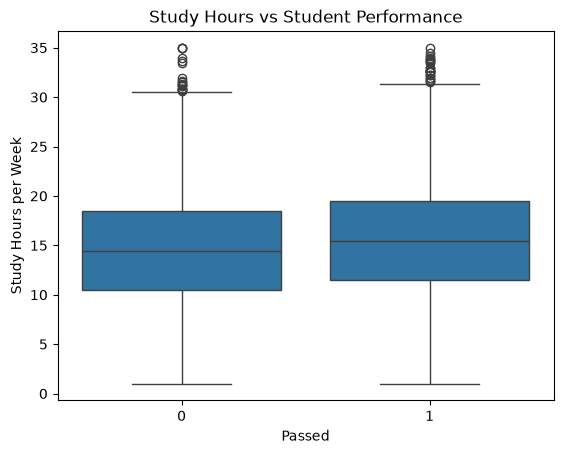

In [66]:
sns.boxplot(x="Passed", y="Study Hours per Week", data=df)
plt.title("Study Hours vs Student Performance")
plt.show()

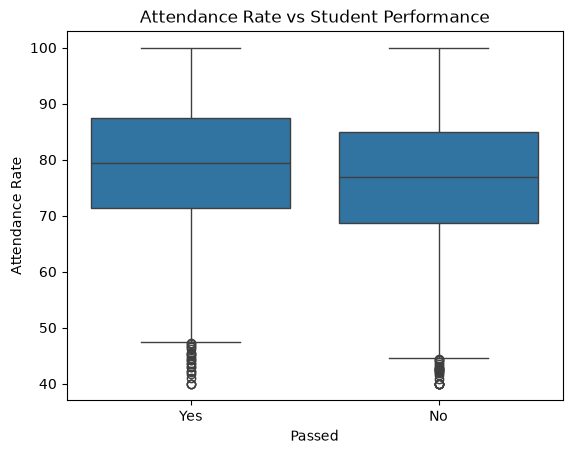

In [19]:
sns.boxplot(x="Passed", y="Attendance Rate", data=df)
plt.title("Attendance Rate vs Student Performance")
plt.show()

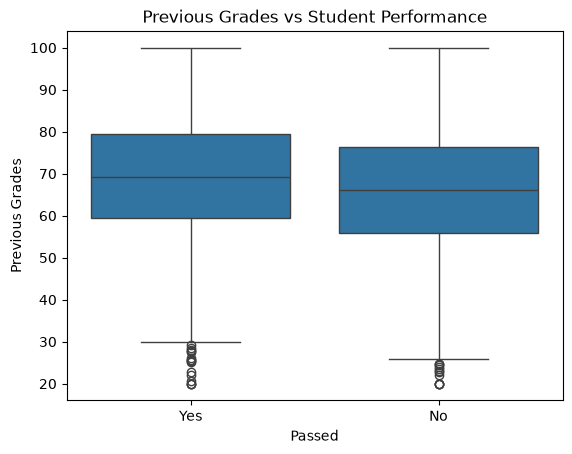

In [20]:
sns.boxplot(x="Passed", y="Previous Grades", data=df)
plt.title("Previous Grades vs Student Performance")
plt.show()

### Correlation Analysis

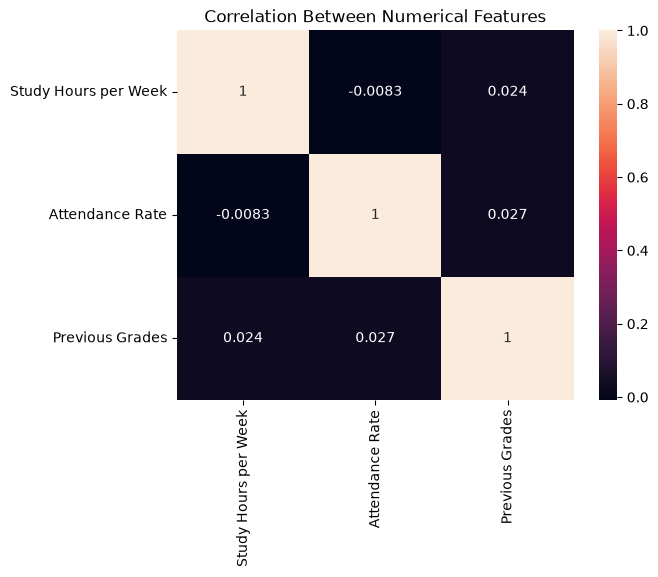

In [21]:
sns.heatmap(df[["Study Hours per Week", "Attendance Rate", "Previous Grades"]].corr(),annot=True)
plt.title("Correlation Between Numerical Features")
plt.show()

## Data Preprocessing

In [22]:
df.isnull().sum()

Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Assignment Score                               0
Midterm Score                                  0
Absences                                       0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df[df["Study Hours per Week"] < 0].shape

(0, 9)

In [25]:
df[df["Attendance Rate"] < 0].shape

(0, 9)

In [26]:
df[df["Previous Grades"] < 0].shape

(0, 9)

In [27]:
df[df["Attendance Rate"] > 100].shape

(0, 9)

In [28]:
df[df["Previous Grades"] > 100].shape

(0, 9)

In [31]:
df.isnull().sum()

Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Assignment Score                               0
Midterm Score                                  0
Absences                                       0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

### Handling Missing Target Values

In [32]:
df = df.dropna(subset=["Passed"])

In [33]:
df.isnull().sum()

Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Assignment Score                               0
Midterm Score                                  0
Absences                                       0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

In [34]:
df["Participation in Extracurricular Activities"] = df["Participation in Extracurricular Activities"].fillna(df["Participation in Extracurricular Activities"].mode()[0])

In [35]:
df["Parent Education Level"] = df["Parent Education Level"].fillna(df["Parent Education Level"].mode()[0])

In [36]:
df.isnull().sum()

Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Assignment Score                               0
Midterm Score                                  0
Absences                                       0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

In [38]:
df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Assignment Score,Midterm Score,Absences,Participation in Extracurricular Activities,Parent Education Level,Passed
0,17.98,69.86,73.22,44.27,57.45,1,Yes,High School,Yes
1,14.17,74.33,72.25,57.23,81.20,4,No,Bachelor,Yes
2,18.89,70.83,53.95,63.78,61.83,3,No,Associate,No
3,24.14,79.33,76.69,74.10,66.45,10,Yes,Master,Yes
4,13.60,92.37,45.65,86.34,76.48,6,Yes,Bachelor,Yes


In [39]:
df["Participation in Extracurricular Activities"] = df["Participation in Extracurricular Activities"].map({"Yes": 1, "No": 0})

In [40]:
df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Assignment Score,Midterm Score,Absences,Participation in Extracurricular Activities,Parent Education Level,Passed
0,17.98,69.86,73.22,44.27,57.45,1,1,High School,Yes
1,14.17,74.33,72.25,57.23,81.20,4,0,Bachelor,Yes
2,18.89,70.83,53.95,63.78,61.83,3,0,Associate,No
3,24.14,79.33,76.69,74.10,66.45,10,1,Master,Yes
4,13.60,92.37,45.65,86.34,76.48,6,1,Bachelor,Yes


In [41]:
df = pd.get_dummies(df,columns=["Parent Education Level"],dtype=int)

In [42]:
df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Assignment Score,Midterm Score,Absences,Participation in Extracurricular Activities,Passed,Parent Education Level_Associate,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,17.98,69.86,73.22,44.27,57.45,1,1,Yes,0,0,0,1,0
1,14.17,74.33,72.25,57.23,81.20,4,0,Yes,0,1,0,0,0
2,18.89,70.83,53.95,63.78,61.83,3,0,No,1,0,0,0,0
3,24.14,79.33,76.69,74.10,66.45,10,1,Yes,0,0,0,0,1
4,13.60,92.37,45.65,86.34,76.48,6,1,Yes,0,1,0,0,0


In [43]:
df["Passed"] = df["Passed "].map({" Yes": 1, " No": 0})

In [44]:
df.head()



,Study Hours per Week,Attendance Rate,Previous Grades,Assignment Score,Midterm Score,Absences,Participation in Extracurricular Activities,Passed,Parent Education Level_Associate,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,17.98,69.86,73.22,44.27,57.45,1,1,1,0,0,0,1,0
1,14.17,74.33,72.25,57.23,81.20,4,0,1,0,1,0,0,0
2,18.89,70.83,53.95,63.78,61.83,3,0,0,1,0,0,0,0
3,24.14,79.33,76.69,74.10,66.45,10,1,1,0,0,0,0,1
4,13.60,92.37,45.65,86.34,76.48,6,1,1,0,1,0,0,0


### Train-Test Split

In [45]:
X = df.drop(" Passed", axis=1)
y = df["Passed"]

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
print(X_train.shape)
print(X_test.shape)

(8000, 12)
(2000, 12)


### Feature Scaling

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Development

### 1 Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [50]:
y_pred_logistic = logistic_model.predict(X_test)

###  K-Nearest Neighbors

In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=11)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [52]:
y_pred_knn = knn_model.predict(X_test)

## Model Evaluation

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [54]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print(" Precision:" , precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:" , f1_score(y_test, y_pred_logistic))

Logistic Regression
Accuracy: 0.629
 Precision: 0.6328125
Recall: 0.6390532544378699
F1 Score: 0.6359175662414132


In [55]:
print("KNN")
print("Accuracy: ", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:" , recall_score(y_test, y_pred_knn))
print("F1 Score: ", f1_score(y_test, y_pred_knn))

KNN
Accuracy:  0.6015
Precision: 0.6092648539778449
Recall: 0.596646942800789
F1 Score:  0.6028898854010961


In [59]:
print(" Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, y_pred_logistic))

print("\n KNN Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

 Logistic Regression Confusion Matrix
[[610 376]
 [366 648]]

 KNN Confusion Matrix
[[598 388]
 [409 605]]


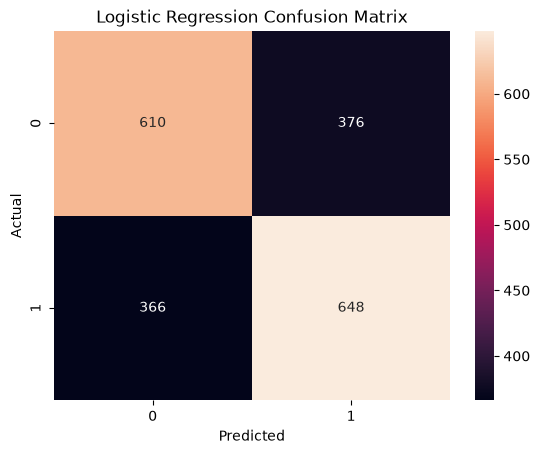

In [57]:
sns.heatmap(confusion_matrix(y_test, y_pred_logistic), annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

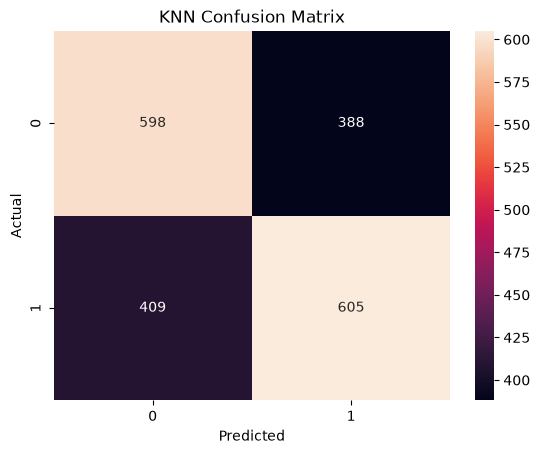

In [58]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Final Model Selection 

In [60]:
results = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred_logistic),accuracy_score(y_test, y_pred_knn)],
    "Precision": [precision_score(y_test, y_pred_logistic),precision_score(y_test, y_pred_knn)],
    "Recall": [recall_score(y_test, y_pred_logistic),recall_score(y_test, y_pred_knn)],
    "F1 Score": [ f1_score(y_test, y_pred_logistic),f1_score(y_test, y_pred_knn)]
}, 
index=["Logistic Regression", "KNN"])
results.round(4)

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.6290,0.6328,0.6391,0.6359
KNN,0.6015,0.6093,0.5966,0.6029


Logistic Regression performed better than KNN based on the evaluation metrics.

## Final Prediction

In [63]:
study_hours = float(input("Study hours per week: "))
attendance = float(input("Attendance rate: "))
grades = float(input("Previous grades: "))
assignment_score = float(input("Assignment score: "))
midterm_score = float(input("Midterm score: "))
absences = float(input("Absences: "))

participation = input("Extracurricular activities (Yes/No): ")
education = input("Parent education (Associate/Bachelor/Doctorate/High School/Master): ")

student = [[
    study_hours,
    attendance,
    grades,
    assignment_score,
    midterm_score,
    absences,
    1 if participation == "Yes" else 0,
    1 if education == "Associate" else 0,
    1 if education == "Bachelor" else 0,
    1 if education == "Doctorate" else 0,
    1 if education == "High School" else 0,
    1 if education == "Master" else 0
]]

student = scaler.transform(student)

prediction = logistic_model.predict(student)

if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Study hours per week:  20
Attendance rate:  85
Previous grades:  75
Assignment score:  80
Midterm score:  78
Absences:  3
Extracurricular activities (Yes/No):  Yes
Parent education (Associate/Bachelor/Doctorate/High School/Master):  Bachelor


Prediction: Pass


C:\Users\sujal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [64]:
study_hours = float(input("Study hours per week: "))
attendance = float(input("Attendance rate: "))
grades = float(input("Previous grades: "))
assignment_score = float(input("Assignment score: "))
midterm_score = float(input("Midterm score: "))
absences = float(input("Absences: "))

participation = input("Extracurricular activities (Yes/No): ")
education = input("Parent education (Associate/Bachelor/Doctorate/High School/Master): ")

student = [[
    study_hours,
    attendance,
    grades,
    assignment_score,
    midterm_score,
    absences,
    1 if participation == "Yes" else 0,
    1 if education == "Associate" else 0,
    1 if education == "Bachelor" else 0,
    1 if education == "Doctorate" else 0,
    1 if education == "High School" else 0,
    1 if education == "Master" else 0
]]

student = scaler.transform(student)

prediction = logistic_model.predict(student)

if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Study hours per week:  2
Attendance rate:  45
Previous grades:  35
Assignment score:  30
Midterm score:  25
Absences:  20
Extracurricular activities (Yes/No):  No
Parent education (Associate/Bachelor/Doctorate/High School/Master):  High School


Prediction: Fail


C:\Users\sujal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
